In [1]:
!pip install cartopy


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sgp4.api import Satrec, jday
from datetime import datetime, timezone, timedelta

In [3]:
with open('starlink.tle') as f:
    lines = f.readlines()

satellites = []
for i in range(0, min(60, len(lines)), 3):
    name = lines[i].strip()
    line1 = lines[i+1].strip()
    line2 = lines[i+2].strip()
    sat = Satrec.twoline2rv(line1, line2)
    satellites.append((name, sat))

print(f"Total lines in file: {len(lines)}")
print(f"Loaded {len(satellites)} satellites")
print("First satellite:", satellites[0][0])

Total lines in file: 32199
Loaded 20 satellites
First satellite: STARLINK-1008


In [4]:
from sgp4.api import jday
from datetime import datetime, timezone, timedelta
import math

def eci_to_latlon(r, t):
    x, y, z = r
    # Earth rotation angle
    theta = math.atan2(y, x)
    # Convert to degrees and account for Earth's rotation
    lon = math.degrees(theta)
    lat = math.degrees(math.asin(z / math.sqrt(x**2 + y**2 + z**2)))
    return lat, lon

# Generate time steps: now, every 30 seconds, for 90 minutes
now = datetime.now(timezone.utc)
times = [now + timedelta(seconds=30*i) for i in range(180)]

# Propagate all 20 satellites
tracks = []
for name, sat in satellites:
    lats, lons = [], []
    for t in times:
        jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
        e, r, v = sat.sgp4(jd, fr)
        if e == 0:
            lat, lon = eci_to_latlon(r, t)
            lats.append(lat)
            lons.append(lon)
    tracks.append((name, lats, lons))

print(f"Propagated {len(tracks)} satellites")
print(f"Sample position of {tracks[0][0]}: lat={tracks[0][1][0]:.2f}, lon={tracks[0][2][0]:.2f}")

Propagated 20 satellites
Sample position of STARLINK-1008: lat=4.62, lon=40.08


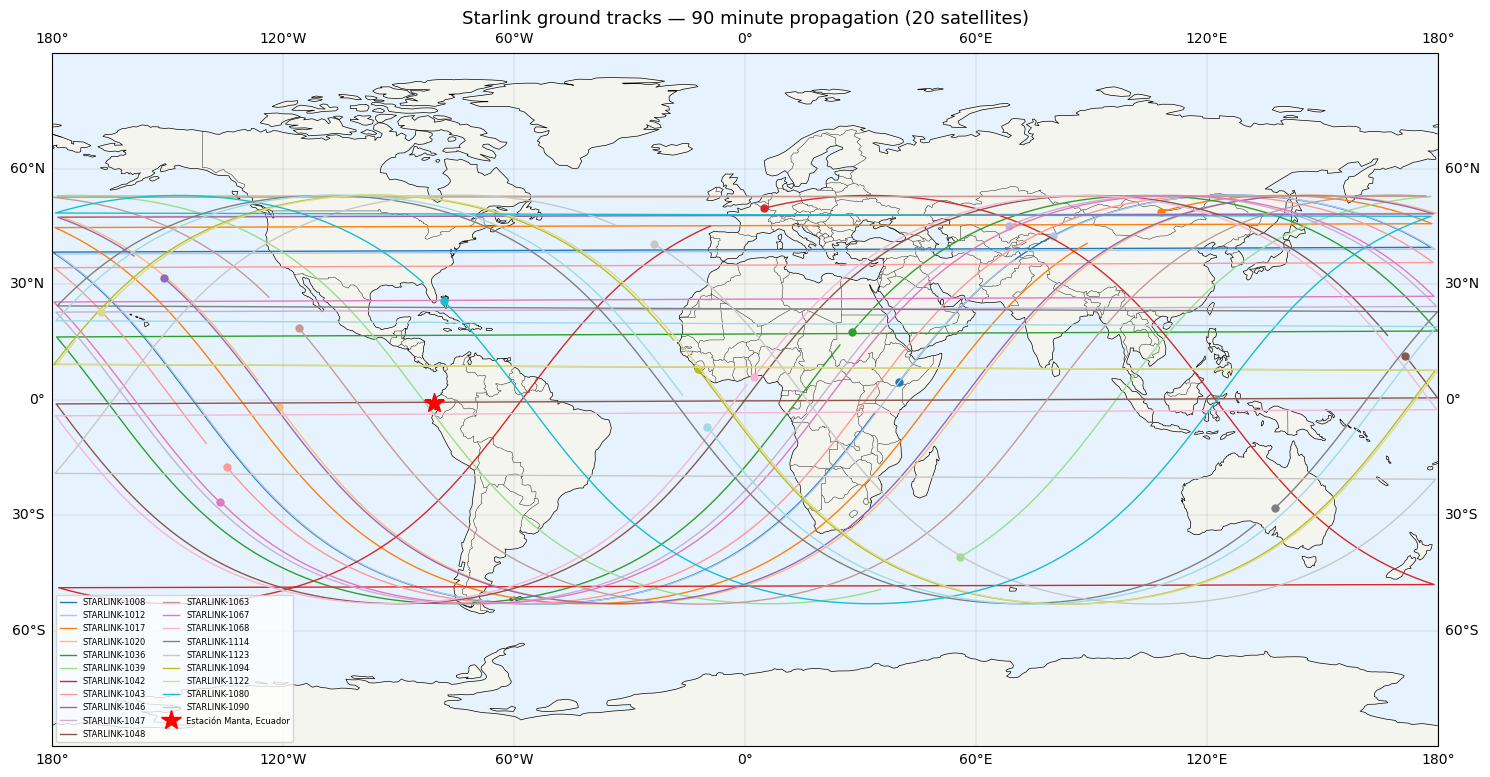

Plot saved to results/


In [5]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.OCEAN, color='#e6f3ff')
ax.add_feature(cfeature.LAND, color='#f5f5f0')
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)

# Plot each satellite's ground track
colors = plt.cm.tab20(range(20))
for i, (name, lats, lons) in enumerate(tracks):
    ax.plot(lons, lats, transform=ccrs.PlateCarree(),
            color=colors[i], linewidth=1, label=name)
    # Mark current position with a dot (only if track is not empty)
    if lons and lats:
        ax.plot(lons[0], lats[0], 'o', transform=ccrs.PlateCarree(),
                color=colors[i], markersize=5)

# Plot Estación Manta, Ecuador as a red star
ax.plot(-80.71, -0.95, '*', transform=ccrs.PlateCarree(),
        color='red', markersize=15, label='Estación Manta, Ecuador')

plt.title('Starlink ground tracks — 90 minute propagation (20 satellites)', fontsize=13)
plt.legend(loc='lower left', fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig('ground_tracks.png', dpi=150)
plt.show()

print("Plot saved to results/")

In [6]:
# Load ALL satellites from the TLE file
all_satellites = []
for i in range(0, len(lines) - 2, 3):
    try:
        name = lines[i].strip()
        line1 = lines[i+1].strip()
        line2 = lines[i+2].strip()
        sat = Satrec.twoline2rv(line1, line2)
        all_satellites.append((name, sat))
    except:
        continue

print(f"Loaded {len(all_satellites)} total satellites")

# Get current position of every satellite
now = datetime.now(timezone.utc)
jd, fr = jday(now.year, now.month, now.day, now.hour, now.minute, now.second)

snapshot_lats = []
snapshot_lons = []
for name, sat in all_satellites:
    e, r, v = sat.sgp4(jd, fr)
    if e == 0:
        lat, lon = eci_to_latlon(r, now)
        snapshot_lats.append(lat)
        snapshot_lons.append(lon)

print(f"Got positions for {len(snapshot_lats)} satellites")

Loaded 10733 total satellites
Got positions for 10724 satellites


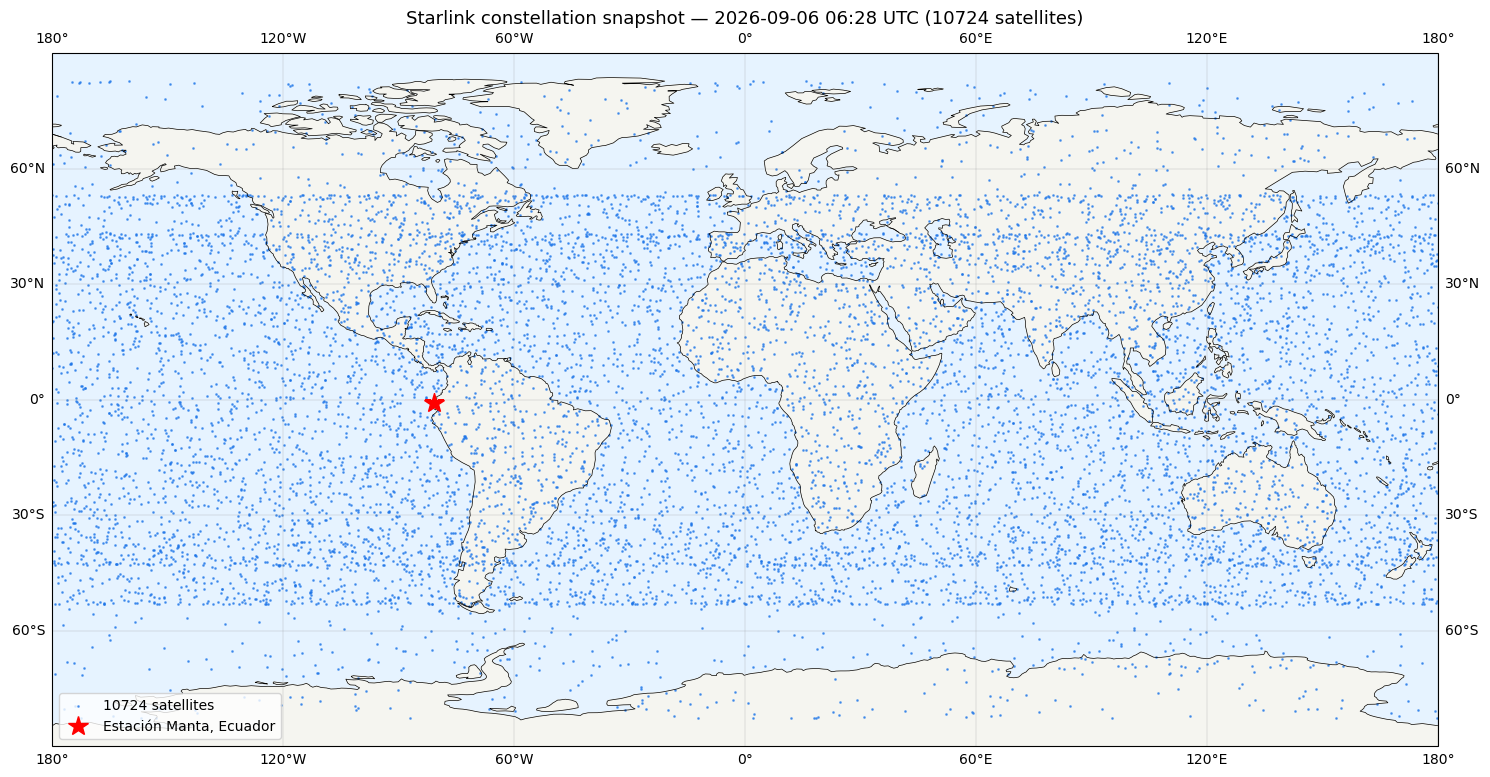

Saved to results/


In [7]:
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Map background
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='#e6f3ff')
ax.add_feature(cfeature.LAND, color='#f5f5f0')
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)

# Plot all satellites as small dots
ax.scatter(snapshot_lons, snapshot_lats,
           transform=ccrs.PlateCarree(),
           s=1, color='#1a73e8', alpha=0.6, label=f'{len(snapshot_lats)} satellites')

# Estación Manta, Ecuador
ax.plot(-80.71, -0.95, '*', transform=ccrs.PlateCarree(),
        color='red', markersize=15, label='Estación Manta, Ecuador')

plt.title(f'Starlink constellation snapshot — {now.strftime("%Y-%m-%d %H:%M")} UTC ({len(snapshot_lats)} satellites)', fontsize=13)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig('constellation_snapshot.png', dpi=150)
plt.show()

print("Saved to results/")